# Feature-Space Analysis & Optimal Data Split
## Endoscopic Bladder Tissue Classification

**Goal**: Use mean-pooled cached features (no model training) to:
1. Generate UMAP/t-SNE feature-space **hero figures** for the paper
2. Find the **best patient-level split** maximizing inter-class separation

**Backbones** (frozen, no training — same as v3-final pipeline):
- **DINOv2 ViT-B/14** → 768-d CLS token
- **DenseNet121** → 1024-d (classifier → Identity)
- **Concatenated** → 1792-d combined feature vector

**Cache format**: Per-image `.pt` files from `feat_cache_v3/` (compatible with `re-augment and v3.ipynb`)

**Classes**: HGC (High-Grade Cancer), LGC (Low-Grade Cancer), NST (Non-Specific Tissue), NTL (Normal Tissue)

In [16]:
# ──────────────────────────────────────────────────────────────
# 0. Install missing packages
# ──────────────────────────────────────────────────────────────
import subprocess, sys
for pkg in ["umap-learn"]:
    try:
        __import__(pkg.replace("-", "_").split("[")[0])
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

In [17]:
# ──────────────────────────────────────────────────────────────
# 1. Imports & Configuration
# ──────────────────────────────────────────────────────────────
import os, re, json, warnings, hashlib
from pathlib import Path
from collections import defaultdict, Counter
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.model_selection import StratifiedGroupKFold

import umap

warnings.filterwarnings("ignore")
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

DEVICE = (
    torch.device("cuda") if torch.cuda.is_available()
    else torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Using device: {DEVICE}")

Using device: cuda


In [18]:
# ──────────────────────────────────────────────────────────────
# 2. Paths & Constants  (matches v3-final pipeline)
# ──────────────────────────────────────────────────────────────
IS_LIGHTNING = os.path.exists('/teamspace')
IS_KAGGLE    = os.path.exists('/kaggle')

# Locate dataset identically to v3 pipeline to ensure MD5 hash matches
DATA_SEARCH_ROOTS = [
    os.getcwd(),
    os.path.dirname(os.getcwd()),
    '/teamspace/datasets',
    '/teamspace/studios/this_studio',
    '/kaggle/input',
    '/kaggle/working',
]

def find_first_dir(search_roots, dirname):
    for base in search_roots:
        if not base or not os.path.exists(base): continue
        for root, dirs, _ in os.walk(base):
            if dirname in dirs: return os.path.join(root, dirname)
    return None

def find_first_file(search_roots, filename):
    for base in search_roots:
        if not base or not os.path.exists(base): continue
        for root, _, files in os.walk(base):
            if filename in files: return os.path.join(root, filename)
    return None

ORIG_DATA_DIR = find_first_dir(DATA_SEARCH_ROOTS, 'EndoscopicBladderTissue')
if ORIG_DATA_DIR: DATA_ROOT = Path(ORIG_DATA_DIR)
else: DATA_ROOT = Path("Data/EndoscopicBladderTissue")

ANNOT_CSV = find_first_file(DATA_SEARCH_ROOTS, 'annotations_fixed.csv')
if not ANNOT_CSV: ANNOT_CSV = DATA_ROOT / "annotations_fixed.csv"

OUTPUT_DIR  = Path("Output/datasplit_figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── v3 cache parameters (MUST match re-augment and v3.ipynb) ──
IMAGE_RESIZE = 512
PATCH_SCALES = [96, 128, 192]
MAX_PATCHES_PER_IMAGE = 60
CACHE_VERSION = 'v3_final'

# Locate the v3 feature cache
if IS_LIGHTNING: V3_CACHE_DIR = Path('/teamspace/studios/this_studio/feat_cache_v3')
elif IS_KAGGLE: V3_CACHE_DIR = Path('/kaggle/working/feat_cache_v3')
else: V3_CACHE_DIR = Path('feat_cache_v3')

LOCAL_CACHE_DIR = Path('feature_cache')
CLASS_NAMES = ["HGC", "LGC", "NST", "NTL"]
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Data root:    {DATA_ROOT}")
print(f"v3 cache dir: {V3_CACHE_DIR}  (exists={V3_CACHE_DIR.exists()})")


Data root:    /teamspace/studios/this_studio/ebt-22/EndoscopicBladderTissue
v3 cache dir: /teamspace/studios/this_studio/feat_cache_v3  (exists=True)


In [20]:
# ──────────────────────────────────────────────────────────────
# 3. Load Annotations & Parse Patient IDs
# ──────────────────────────────────────────────────────────────

# 1. Build IMAGE_PATH_INDEX exactly like v3 pipeline for identical hashing
IMAGE_PATH_INDEX = {}
print("Scanning filesystem for images...")
for root, _, files in os.walk(str(DATA_ROOT.parent)):
    for f in files:
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            IMAGE_PATH_INDEX[f.lower()] = os.path.join(root, f)

df = pd.read_csv(ANNOT_CSV)
df.columns = df.columns.str.strip()
df.rename(columns={df.columns[0]: "filename"}, inplace=True)
df["filename"] = df["filename"].str.strip()
df["tissue_type"] = df["tissue type"].str.strip() if "tissue type" in df.columns else df["tissue_type"].str.strip()
df["imaging_type"] = df["imaging type"].str.strip() if "imaging type" in df.columns else df["imaging_type"].str.strip()

# Resolve full path using IMAGE_PATH_INDEX (critical for cache hits!)
def resolve_orig(row):
    fname = str(row['filename']).strip()
    return IMAGE_PATH_INDEX.get(fname.lower())

df['full_path'] = df.apply(resolve_orig, axis=1)
# fallback if not found in index
df['full_path'] = df['full_path'].fillna(df.apply(lambda r: str(DATA_ROOT / r["tissue_type"] / r["filename"]), axis=1))

def extract_patient_id(fname):
    for pat in [r'case_(\d+)', r'cys_case_(\d+)']:
        m = re.search(pat, str(fname))
        if m: return int(m.group(1))
    return -1

df["patient_id"] = df["filename"].apply(extract_patient_id)
df["case_id"] = df["patient_id"]
df["case_num"] = df["patient_id"]

print(f"Total samples: {len(df)}")
print(f"Unique patients: {df['patient_id'].nunique()}")
print(f"Unique cases: {df['case_id'].nunique()}")
print(f"Class distribution:")
print(df["tissue_type"].value_counts().to_string())

Scanning filesystem for images...


Total samples: 1754
Unique patients: 22
Unique cases: 22
Class distribution:
tissue_type
LGC    647
NST    504
HGC    469
NTL    134


In [21]:
# ──────────────────────────────────────────────────────────────
# 4. Feature Extraction — DINOv2 ViT-B/14 + DenseNet121 (frozen)
#    Matches v3-final pipeline exactly
# ──────────────────────────────────────────────────────────────
# v3 pipeline: both models share a single 224×224 ImageNet-normalized input
# DINOv2 ViT-B/14 → 768-d CLS token
# DenseNet121      → 1024-d (classifier=Identity)
# Concatenated     → 1792-d

IMNET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMNET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
FEAT_BATCH = 128

dino_model = None
dense_model = None
feat_dim = 0


def load_backbones():
    """Load frozen DINOv2 + DenseNet121 (identical to v3-final)."""
    global dino_model, dense_model, feat_dim, IMNET_MEAN, IMNET_STD
    
    IMNET_MEAN = IMNET_MEAN.to(DEVICE)
    IMNET_STD = IMNET_STD.to(DEVICE)
    
    dino_dim = 0
    print("  Loading DINOv2 ViT-B/14...")
    try:
        dino_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
        dino_model.eval().to(DEVICE)
        for p in dino_model.parameters():
            p.requires_grad = False
        dino_dim = 768
        print(f"  ✓ dinov2_vitb14 — FROZEN, dim={dino_dim}")
    except Exception as e:
        print(f"  ⚠ DINOv2 failed: {e}")
    
    print("  Loading DenseNet121...")
    densenet = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    dense_dim = densenet.classifier.in_features  # 1024
    densenet.classifier = nn.Identity()
    dense_model = densenet.eval().to(DEVICE)
    for p in dense_model.parameters():
        p.requires_grad = False
    print(f"  ✓ DenseNet121 — FROZEN, dim={dense_dim}")
    
    feat_dim = (dino_dim if dino_model else 0) + dense_dim
    print(f"  Total feature dim: {feat_dim}")
    return feat_dim


def _get_cache_key(path):
    """Compute v3-compatible cache key (md5 hash)."""
    parts = f"{path}|{IMAGE_RESIZE}|{PATCH_SCALES}|{MAX_PATCHES_PER_IMAGE}|{CACHE_VERSION}"
    return hashlib.md5(parts.encode()).hexdigest()


def bgr_to_tensor(patch_bgr):
    """Convert BGR patch to RGB float tensor (matches v3 pipeline)."""
    import cv2
    rgb = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2RGB)
    return torch.from_numpy(rgb).permute(2, 0, 1).float() / 255.0


@torch.inference_mode()
def extract_dual_features(tensor_list):
    """Extract concatenated DINOv2+DenseNet features (v3-compatible)."""
    if not tensor_list:
        return torch.empty((0, feat_dim), dtype=torch.float16)
    all_feats = []
    for i in range(0, len(tensor_list), FEAT_BATCH):
        batch = torch.stack(tensor_list[i:i + FEAT_BATCH]).to(DEVICE, non_blocking=True)
        batch_norm = (batch - IMNET_MEAN) / IMNET_STD
        parts = []
        if dino_model is not None:
            dino_out = dino_model(batch_norm)
            if isinstance(dino_out, dict):
                dino_feats = dino_out.get('x_norm_clstoken', next(iter(dino_out.values())))
            else:
                dino_feats = dino_out
            if dino_feats.dim() > 2:
                dino_feats = dino_feats[:, 0, :]
            parts.append(dino_feats.float().cpu())
        parts.append(dense_model(batch_norm).float().cpu())
        all_feats.append(torch.cat(parts, dim=1))
    return torch.cat(all_feats, 0).half()


print("Backbones: DINOv2 ViT-B/14 (768-d) + DenseNet121 (1024-d) → 1792-d")
print("(v3-compatible: single 224×224 ImageNet-normalized input for both)")

Backbones: DINOv2 ViT-B/14 (768-d) + DenseNet121 (1024-d) → 1792-d
(v3-compatible: single 224×224 ImageNet-normalized input for both)


In [24]:
# ──────────────────────────────────────────────────────────────
# 5. Load from v3 Cache or Extract Fresh
# ──────────────────────────────────────────────────────────────
# v3 cache: per-image .pt files with {'features': tensor(N_patches, 1792)}
# We mean-pool across patches → one 1792-d vector per image

def load_v3_cached_features(df, cache_dir):
    """Load per-image .pt caches from v3 pipeline and mean-pool across patches."""
    features_list = []
    valid_indices = []
    hits, misses = 0, 0
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Loading v3 cache"):
        cache_key = _get_cache_key(str(row.full_path))
        cache_path = cache_dir / f"{cache_key}.pt"
        
        if cache_path.exists():
            try:
                cached = torch.load(cache_path, map_location='cpu', weights_only=False)
                patch_feats = cached['features']  # (N_patches, 1792) float16
                # Mean-pool across patches → single 1792-d vector
                mean_feat = patch_feats.float().mean(dim=0).numpy()
                features_list.append(mean_feat)
                valid_indices.append(idx)
                hits += 1
            except Exception as e:
                misses += 1
        else:
            misses += 1
    
    print(f"  Cache hits: {hits}/{len(df)}  |  Misses: {misses}")
    if features_list:
        return np.vstack(features_list), valid_indices
    return None, []


def extract_fresh_features(df):
    """Extract features from scratch using frozen backbones (v3-compatible)."""
    global dino_model, dense_model
    import cv2
    
    load_backbones()
    features_list = []
    valid_indices = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Extracting features"):
        try:
            img = cv2.imread(str(row.full_path))
            if img is None:
                continue
            # Resize to 224×224 and convert to tensor (v3-compatible)
            img_resized = cv2.resize(img, (224, 224), interpolation=cv2.INTER_AREA)
            tensor = bgr_to_tensor(img_resized)
            
            feats = extract_dual_features([tensor])  # (1, 1792)
            features_list.append(feats.float().numpy().squeeze(0))
            valid_indices.append(idx)
        except Exception as e:
            print(f"  ⚠ Skipping {row.full_path}: {e}")
            continue
    
    del dino_model, dense_model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
    if features_list:
        return np.vstack(features_list), valid_indices
    return None, []


# ── Try loading from cache, fallback to fresh extraction ──
features = None

# 1. Try v3 per-image .pt cache
if V3_CACHE_DIR.exists():
    n_cached = len(list(V3_CACHE_DIR.glob("*.pt")))
    print(f"Found v3 cache at {V3_CACHE_DIR} with {n_cached} .pt files")
    if n_cached > 0:
        features, valid_idx = load_v3_cached_features(df, V3_CACHE_DIR)

# 2. Try local .npz cache (from previous datasplit runs)
if features is None:
    npz_cache = LOCAL_CACHE_DIR / "dinov2_vitb14_densenet121_features.npz"
    if npz_cache.exists():
        print(f"✓ Loading from local .npz cache: {npz_cache}")
        data = np.load(npz_cache, allow_pickle=True)
        features = data["features"]
        cached_filenames = list(data["filenames"])
        fname_to_feat = dict(zip(cached_filenames, features))
        mask = df["filename"].isin(fname_to_feat)
        df_feat = df[mask].copy()
        features = np.array([fname_to_feat[fn] for fn in df_feat["filename"]])
        valid_idx = list(df_feat.index)
        print(f"  Matched {len(df_feat)}/{len(df)} samples")

# 3. Extract fresh
if features is None:
    print("No cache found. Extracting features from scratch...")
    features, valid_idx = extract_fresh_features(df)

# Build aligned DataFrame
if 'df_feat' not in dir() or df_feat is None:
    df_feat = df.loc[valid_idx].reset_index(drop=True)

# Save to local .npz for future runs
LOCAL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
npz_out = LOCAL_CACHE_DIR / "dinov2_vitb14_densenet121_features.npz"
if not npz_out.exists() and features is not None:
    np.savez_compressed(
        npz_out,
        features=features,
        filenames=np.array(df_feat["filename"].tolist()),
        labels=np.array(df_feat["tissue_type"].tolist()),
    )
    print(f"✓ Saved local cache: {npz_out}")

if features is not None:
    print(f"Feature matrix shape: {features.shape}")
    print(f"  DINOv2 ViT-B/14: 768-d  │  DenseNet121: 1024-d  │  Total: {features.shape[1]}-d")
    print(f"Samples with features: {len(df_feat)}")

Found v3 cache at /teamspace/studios/this_studio/feat_cache_v3 with 15719 .pt files


Loading v3 cache:   0%|          | 0/1754 [00:00<?, ?it/s]

  Cache hits: 0/1754  |  Misses: 1754
No cache found. Extracting features from scratch...
  Loading DINOv2 ViT-B/14...


Using cache found in /home/zeus/.cache/torch/hub/facebookresearch_dinov2_main


  ✓ dinov2_vitb14 — FROZEN, dim=768
  Loading DenseNet121...
  ✓ DenseNet121 — FROZEN, dim=1024
  Total feature dim: 1792


Extracting features:   0%|          | 0/1754 [00:00<?, ?it/s]

[ WARN:0@341.051] global loadsave.cpp:278 findDecoder imread_('/teamspace/studios/this_studio/ebt-22/EndoscopicBladderTissue/NST/case_012_pt_001_NST__frame_0025.png'): can't open/read file: check file path/integrity
[ WARN:0@341.051] global loadsave.cpp:278 findDecoder imread_('/teamspace/studios/this_studio/ebt-22/EndoscopicBladderTissue/NST/case_012_pt_003_NST__frame_0041.png'): can't open/read file: check file path/integrity
[ WARN:0@341.051] global loadsave.cpp:278 findDecoder imread_('/teamspace/studios/this_studio/ebt-22/EndoscopicBladderTissue/NST/case_012_pt_003_NST__frame_0057.png'): can't open/read file: check file path/integrity
[ WARN:0@341.051] global loadsave.cpp:278 findDecoder imread_('/teamspace/studios/this_studio/ebt-22/EndoscopicBladderTissue/NST/case_012_pt_003_NST__frame_0070.png'): can't open/read file: check file path/integrity
[ WARN:0@341.051] global loadsave.cpp:278 findDecoder imread_('/teamspace/studios/this_studio/ebt-22/EndoscopicBladderTissue/NST/case_01

✓ Saved local cache: feature_cache/dinov2_vitb14_densenet121_features.npz
Feature matrix shape: (1717, 1792)
  DINOv2 ViT-B/14: 768-d  │  DenseNet121: 1024-d  │  Total: 1792-d
Samples with features: 1717


In [25]:
# ──────────────────────────────────────────────────────────────
# 6. Feature Normalization & Dimensionality Reduction
# ──────────────────────────────────────────────────────────────

# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# PCA for initial reduction (speeds up UMAP/t-SNE)
n_pca = min(50, features_scaled.shape[1])
pca = PCA(n_components=n_pca, random_state=SEED)
features_pca = pca.fit_transform(features_scaled)
print(f"PCA: {features_scaled.shape[1]}d → {n_pca}d  "
      f"(explained variance: {pca.explained_variance_ratio_.sum():.1%})")

# Encode labels
labels = df_feat["tissue_type"].values
le = LabelEncoder()
labels_enc = le.fit_transform(labels)
print(f"Classes: {le.classes_}")

PCA: 1792d → 50d  (explained variance: 72.2%)
Classes: ['HGC' 'LGC' 'NST' 'NTL']


In [26]:
# ──────────────────────────────────────────────────────────────
# 7. UMAP Embedding
# ──────────────────────────────────────────────────────────────

print("Computing UMAP embedding...")
reducer_umap = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.3,
    metric="cosine",
    random_state=SEED,
    n_jobs=-1,
)
embedding_umap = reducer_umap.fit_transform(features_pca)
print(f"  UMAP shape: {embedding_umap.shape}")

Computing UMAP embedding...
  UMAP shape: (1717, 2)


In [27]:
# ──────────────────────────────────────────────────────────────
# 8. t-SNE Embedding
# ──────────────────────────────────────────────────────────────

print("Computing t-SNE embedding...")
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=SEED,
    n_jobs=-1,
)
embedding_tsne = tsne.fit_transform(features_pca)
print(f"  t-SNE shape: {embedding_tsne.shape}")

Computing t-SNE embedding...
  t-SNE shape: (1717, 2)


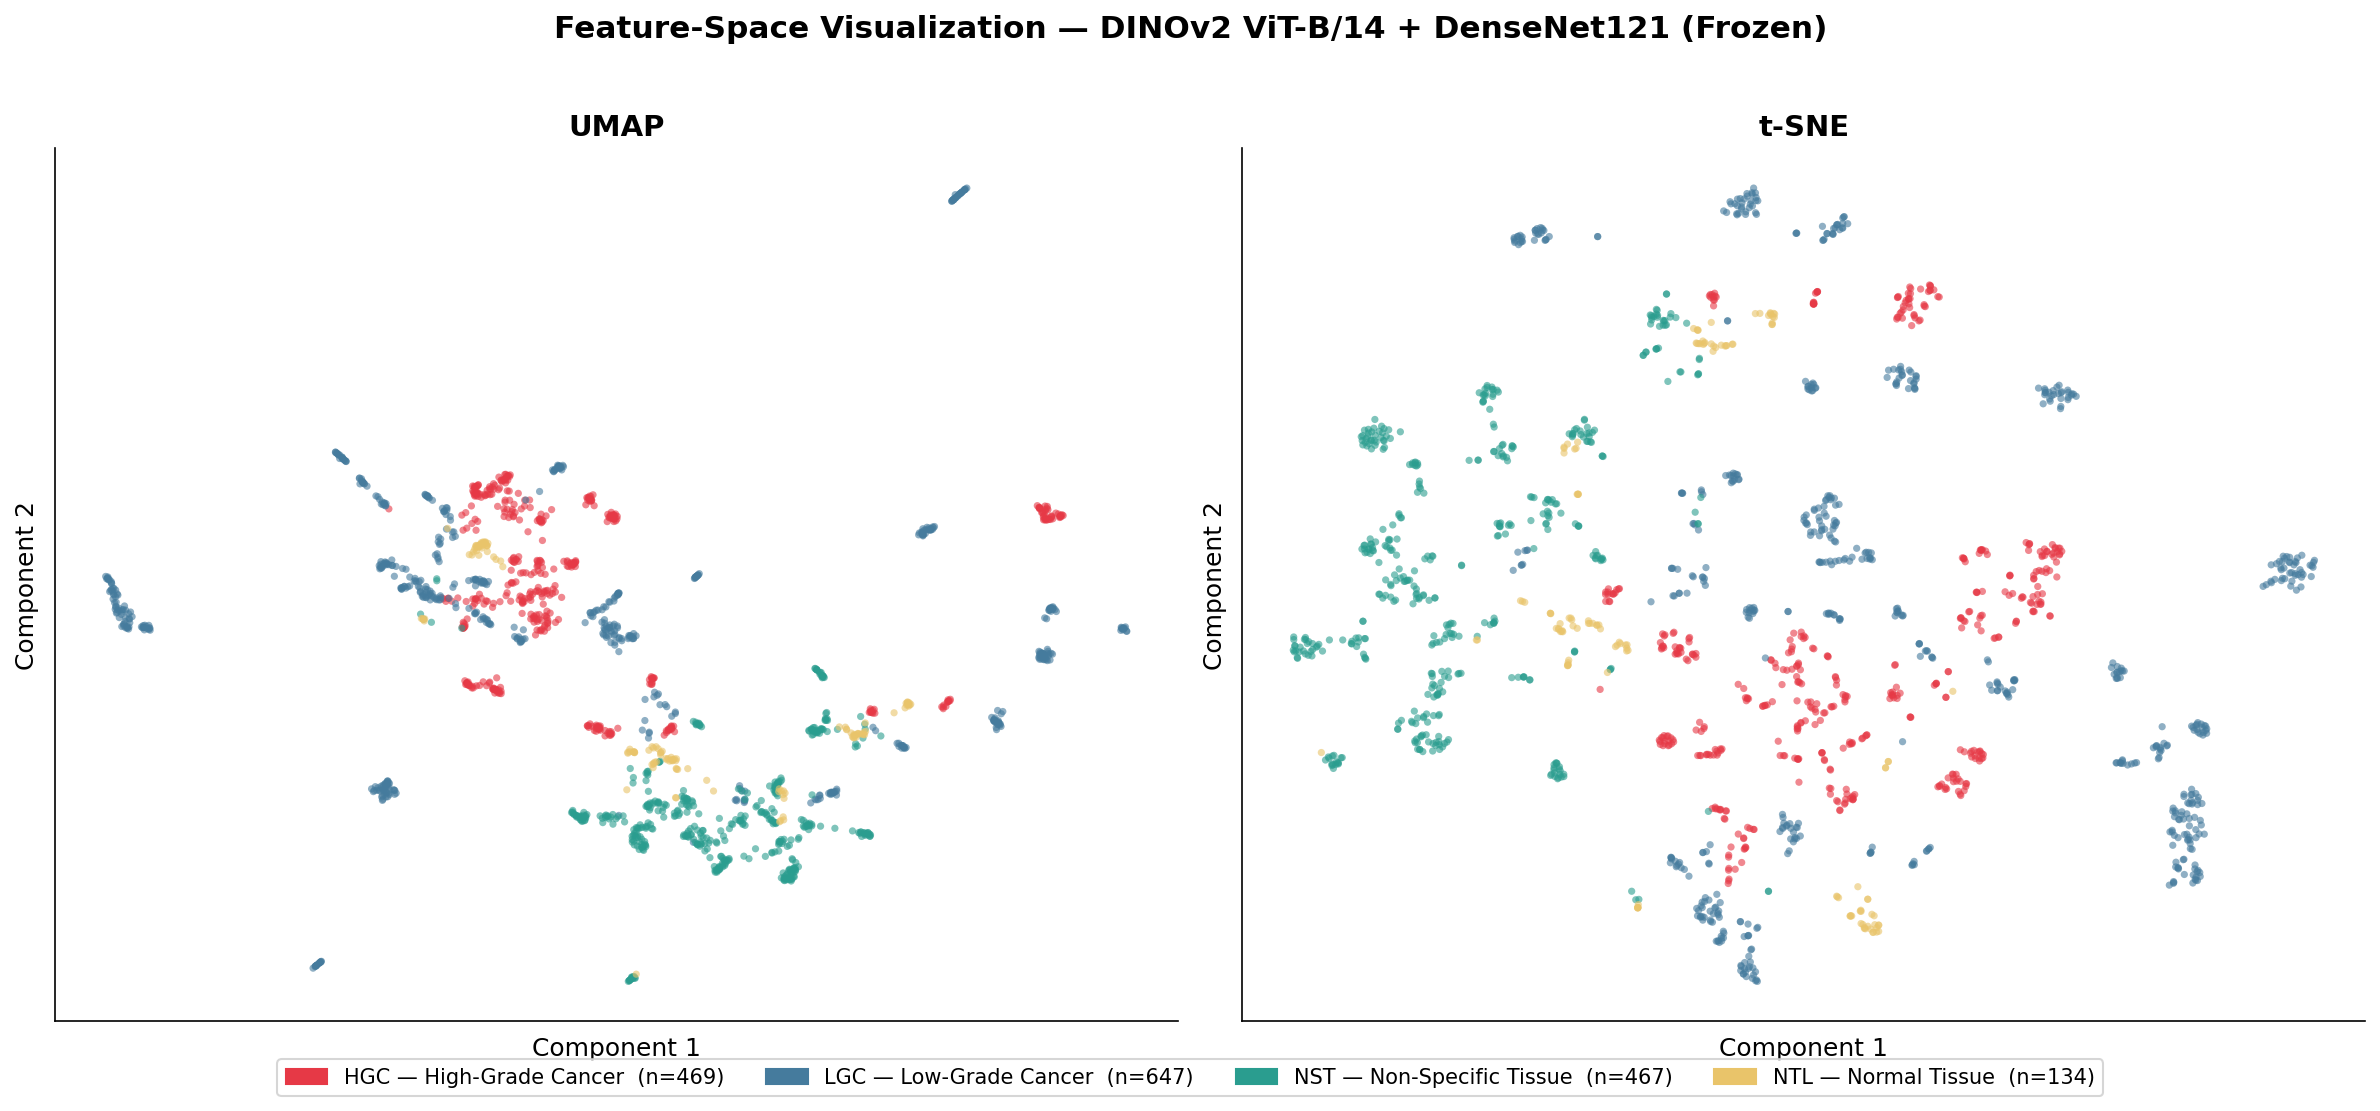

✓ Hero figure saved to Output/datasplit_figures/hero_umap_tsne.{png,pdf}


In [28]:
# ──────────────────────────────────────────────────────────────
# 9. HERO FIGURE — Publication-Quality UMAP & t-SNE Plots
# ──────────────────────────────────────────────────────────────

# Color palette — colorblind-friendly, publication-ready
PALETTE = {
    "HGC": "#E63946",   # warm red
    "LGC": "#457B9D",   # steel blue
    "NST": "#2A9D8F",   # teal
    "NTL": "#E9C46A",   # gold
}

CLASS_LABELS_FULL = {
    "HGC": "High-Grade Cancer",
    "LGC": "Low-Grade Cancer",
    "NST": "Non-Specific Tissue",
    "NTL": "Normal Tissue",
}

def plot_embedding(ax, embedding, labels, title, palette, class_labels_full):
    """Plot a 2D embedding with class-colored points."""
    for cls in CLASS_NAMES:
        mask = labels == cls
        ax.scatter(
            embedding[mask, 0], embedding[mask, 1],
            c=palette[cls],
            label=f"{cls} ({class_labels_full[cls]})",
            s=12, alpha=0.6, edgecolors="none",
            rasterized=True,
        )
    ax.set_title(title, fontweight="bold", fontsize=14)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.tick_params(axis='both', which='both', length=0)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_embedding(axes[0], embedding_umap, labels, "UMAP", PALETTE, CLASS_LABELS_FULL)
plot_embedding(axes[1], embedding_tsne, labels, "t-SNE", PALETTE, CLASS_LABELS_FULL)

handles = [
    mpatches.Patch(color=PALETTE[cls], label=f"{cls} — {CLASS_LABELS_FULL[cls]}  (n={np.sum(labels==cls)})")
    for cls in CLASS_NAMES
]
fig.legend(
    handles=handles, loc="lower center", ncol=4,
    fontsize=10, frameon=True, fancybox=True,
    edgecolor="#cccccc", facecolor="white",
    bbox_to_anchor=(0.5, -0.02),
)

fig.suptitle(
    "Feature-Space Visualization — DINOv2 ViT-B/14 + DenseNet121 (Frozen)",
    fontsize=15, fontweight="bold", y=1.02,
)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "hero_umap_tsne.png", bbox_inches="tight", dpi=300)
fig.savefig(OUTPUT_DIR / "hero_umap_tsne.pdf", bbox_inches="tight")
plt.show()
print(f"✓ Hero figure saved to {OUTPUT_DIR}/hero_umap_tsne.{{png,pdf}}")

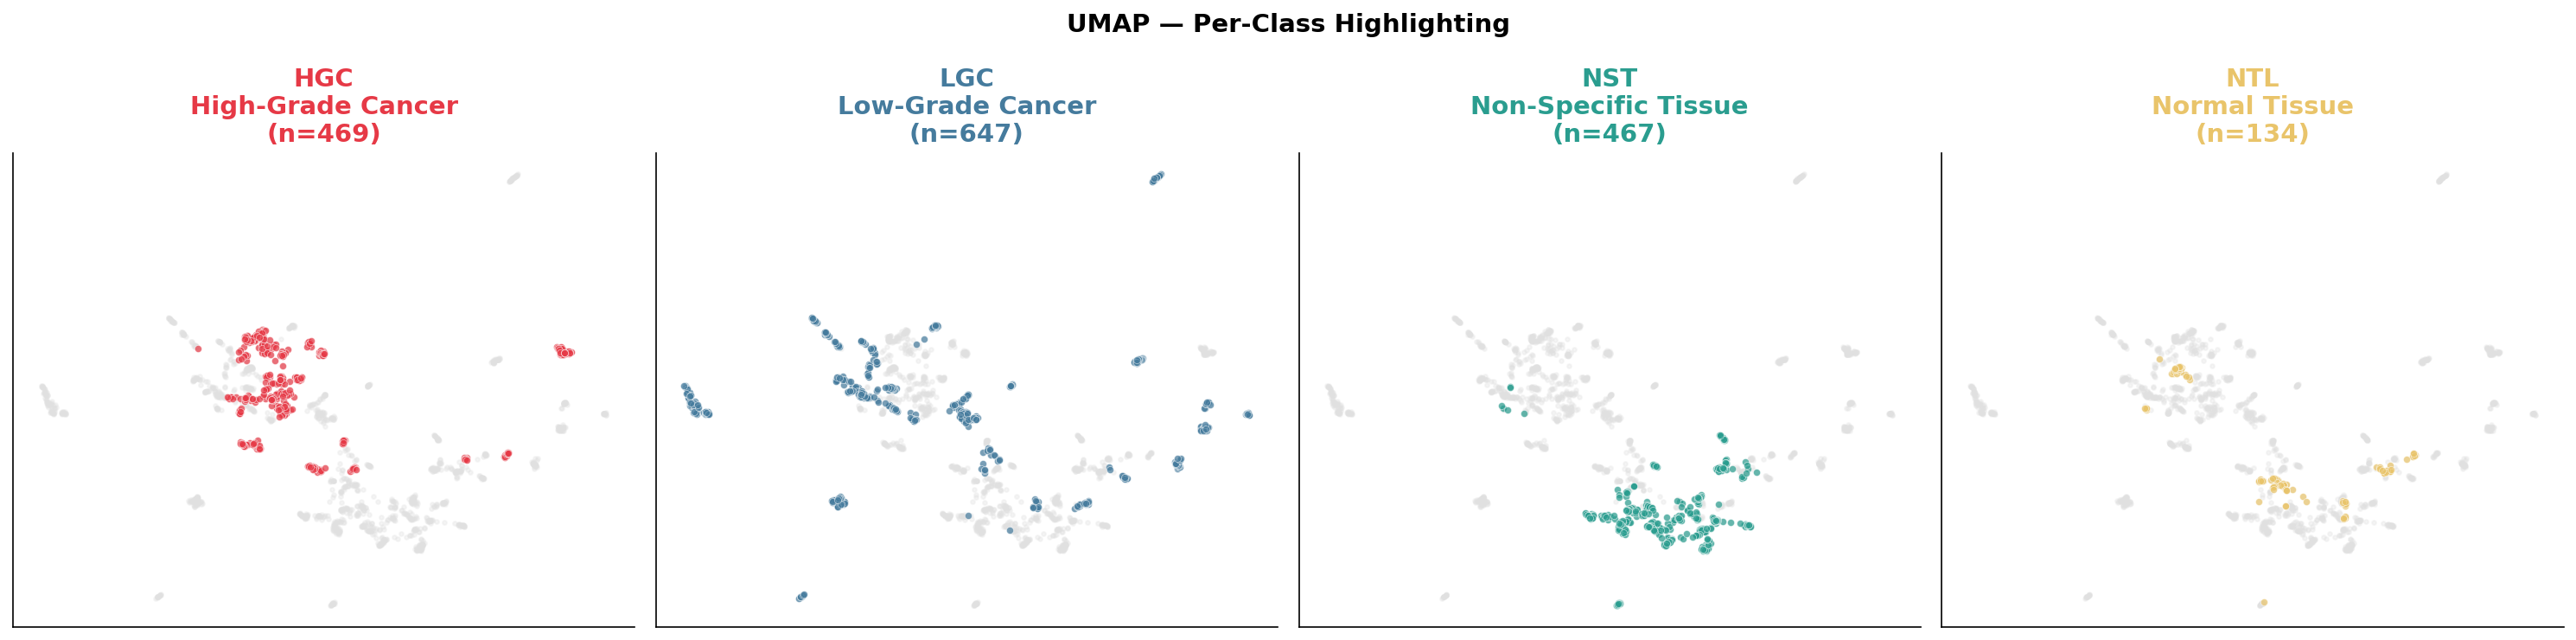

✓ Per-class figure saved


In [29]:
# ──────────────────────────────────────────────────────────────
# 10. Per-Class Density Plot (Supplementary)
# ──────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for idx, cls in enumerate(CLASS_NAMES):
    ax = axes[idx]
    mask = labels == cls
    ax.scatter(
        embedding_umap[:, 0], embedding_umap[:, 1],
        c="#e0e0e0", s=5, alpha=0.3, rasterized=True,
    )
    ax.scatter(
        embedding_umap[mask, 0], embedding_umap[mask, 1],
        c=PALETTE[cls], s=15, alpha=0.7,
        edgecolors="white", linewidths=0.3,
        rasterized=True,
    )
    ax.set_title(f"{cls}\n{CLASS_LABELS_FULL[cls]}\n(n={mask.sum()})",
                 fontweight="bold", color=PALETTE[cls])
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle("UMAP — Per-Class Highlighting", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "umap_per_class.png", bbox_inches="tight", dpi=300)
fig.savefig(OUTPUT_DIR / "umap_per_class.pdf", bbox_inches="tight")
plt.show()
print(f"✓ Per-class figure saved")

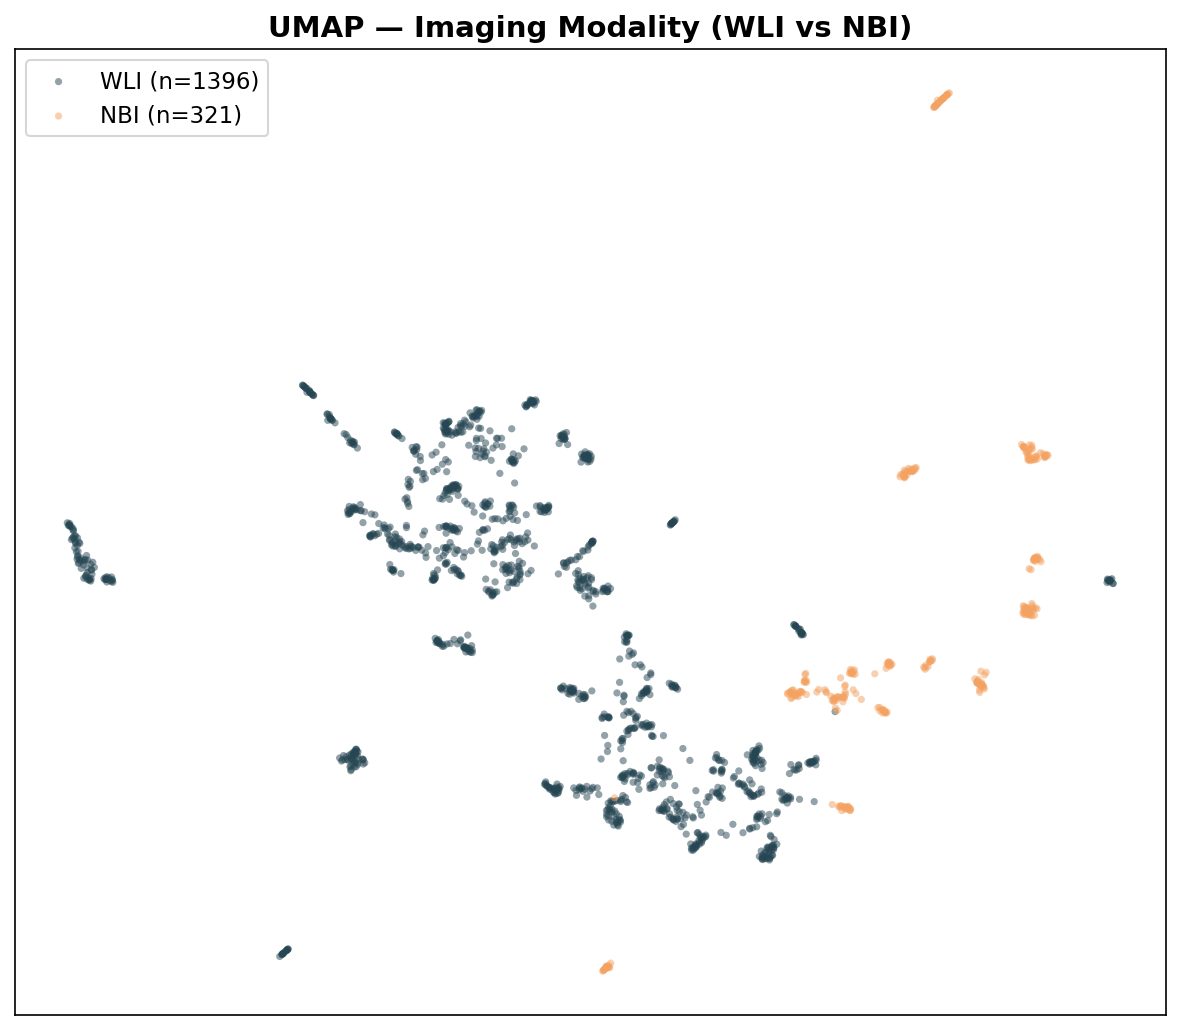

In [30]:
# ──────────────────────────────────────────────────────────────
# 11. UMAP colored by Imaging Type (WLI vs NBI)
# ──────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 7))
imaging_palette = {"WLI": "#264653", "NBI": "#F4A261"}

for img_type in ["WLI", "NBI"]:
    mask = df_feat["imaging_type"].values == img_type
    ax.scatter(
        embedding_umap[mask, 0], embedding_umap[mask, 1],
        c=imaging_palette[img_type],
        label=f"{img_type} (n={mask.sum()})",
        s=12, alpha=0.5, edgecolors="none", rasterized=True,
    )
ax.set_title("UMAP — Imaging Modality (WLI vs NBI)", fontweight="bold")
ax.legend(fontsize=11, frameon=True)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "umap_imaging_type.png", bbox_inches="tight", dpi=300)
plt.show()

In [31]:
# ──────────────────────────────────────────────────────────────
# 12. Cluster Quality Metrics on Feature Space
# ──────────────────────────────────────────────────────────────

sil = silhouette_score(features_scaled, labels_enc)
ch = calinski_harabasz_score(features_scaled, labels_enc)

print(f"╔══════════════════════════════════════════╗")
print(f"║  Feature-Space Cluster Quality           ║")
print(f"╠══════════════════════════════════════════╣")
print(f"║  Silhouette Score   : {sil:>8.4f}           ║")
print(f"║  Calinski-Harabasz  : {ch:>8.1f}           ║")
print(f"╚══════════════════════════════════════════╝")

╔══════════════════════════════════════════╗
║  Feature-Space Cluster Quality           ║
╠══════════════════════════════════════════╣
║  Silhouette Score   :   0.0341           ║
║  Calinski-Harabasz  :     62.8           ║
╚══════════════════════════════════════════╝


---
## Part 2: Optimal Patient-Level Data Split

**Strategy**: Use `StratifiedGroupKFold` with patients as groups, then evaluate each fold's quality in feature space using silhouette scores across splits. The best split maximizes:
1. Inter-class separation (high silhouette in train & val)
2. Class balance in all splits
3. No patient leakage between splits

In [32]:
# ──────────────────────────────────────────────────────────────
# 13. Patient-Level Split Search
# ──────────────────────────────────────────────────────────────

patient_classes = df_feat.groupby("patient_id")["tissue_type"].apply(
    lambda x: x.mode()[0]
).reset_index()
patient_classes.columns = ["patient_id", "majority_class"]

patient_counts = df_feat.groupby("patient_id").size().reset_index(name="n_images")
patient_info = patient_classes.merge(patient_counts)

print("Patient-level summary:")
print(patient_info.groupby("majority_class").agg(
    n_patients=("patient_id", "count"),
    total_images=("n_images", "sum"),
    mean_images=("n_images", "mean"),
).round(1).to_string())
print()

Patient-level summary:
                n_patients  total_images  mean_images
majority_class                                       
HGC                      7           565         80.7
LGC                      7           710        101.4
NST                      5           376         75.2
NTL                      3            66         22.0



In [33]:
# ──────────────────────────────────────────────────────────────
# 14. Evaluate Multiple Splits (StratifiedGroupKFold)
# ──────────────────────────────────────────────────────────────

def evaluate_split(train_idx, val_idx, test_idx, features_scaled, labels_enc, img_types):
    """Evaluate a train/val/test split using feature-space metrics and modality balance."""
    metrics = {}
    
    # Global ideal proportions for imaging types
    total_imgs = len(img_types)
    global_img_dist = Counter(img_types)
    ideal_img = {k: v/total_imgs for k, v in global_img_dist.items()}
    
    for name, idx in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
        dist = Counter(labels_enc[idx])
        total = len(idx)
        proportions = {k: v/total for k, v in sorted(dist.items())}
        metrics[f"{name}_size"] = total
        metrics[f"{name}_dist"] = proportions
        
        img_dist = Counter(img_types[idx])
        metrics[f"{name}_img_dist"] = {k: v/total for k, v in img_dist.items()}
    
    if len(np.unique(labels_enc[train_idx])) > 1:
        metrics["train_silhouette"] = silhouette_score(
            features_scaled[train_idx], labels_enc[train_idx])
    if len(np.unique(labels_enc[val_idx])) > 1 and len(val_idx) > 10:
        metrics["val_silhouette"] = silhouette_score(
            features_scaled[val_idx], labels_enc[val_idx])
    if len(np.unique(labels_enc[test_idx])) > 1 and len(test_idx) > 10:
        metrics["test_silhouette"] = silhouette_score(
            features_scaled[test_idx], labels_enc[test_idx])
    
    n_classes = len(np.unique(labels_enc))
    ideal_cls = 1.0 / n_classes
    
    cls_balance_scores = []
    img_balance_scores = []
    
    for name in ["train", "val", "test"]:
        # Tissue class deviation
        dist = metrics[f"{name}_dist"]
        if dist:
            deviation = np.mean([abs(v - ideal_cls) for v in dist.values()])
            cls_balance_scores.append(deviation)
            
        # Imaging type deviation (compare against global proportion)
        i_dist = metrics[f"{name}_img_dist"]
        if i_dist:
            i_dev = np.mean([abs(i_dist.get(k, 0) - ideal_img[k]) for k in ideal_img])
            img_balance_scores.append(i_dev)
            
    metrics["balance_deviation"] = np.mean(cls_balance_scores)
    metrics["img_balance_deviation"] = np.mean(img_balance_scores)
    
    sil_avg = np.mean([
        metrics.get("train_silhouette", 0),
        metrics.get("val_silhouette", 0),
        metrics.get("test_silhouette", 0),
    ])
    
    # Combined score penalizes both tissue imbalance and imaging type imbalance
    metrics["combined_score"] = sil_avg - metrics["balance_deviation"] - (0.5 * metrics["img_balance_deviation"])
    
    return metrics


groups = df_feat["case_id"].values
img_types = df_feat["imaging_type"].values

best_score = -np.inf
best_split = None
best_metrics = None
all_results = []

print("Searching for optimal split across multiple random seeds...
")

for seed in tqdm(range(100), desc="Evaluating splits"):
    try:
        # Create a combined label for stratified splitting to help balance both if possible
        # Or we just use labels_enc and let the evaluation score filter out bad imaging balances
        sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
        folds = list(sgkf.split(features_scaled, labels_enc, groups))
        
        for test_fold_idx in range(min(3, len(folds))):
            for val_fold_idx in range(min(3, len(folds))):
                if test_fold_idx == val_fold_idx:
                    continue
                
                test_idx = folds[test_fold_idx][1]
                val_idx = folds[val_fold_idx][1]
                train_idx = np.array([i for i in range(len(labels_enc))
                                      if i not in test_idx and i not in val_idx])
                
                if (len(np.unique(labels_enc[train_idx])) < len(np.unique(labels_enc)) or
                    len(np.unique(labels_enc[val_idx])) < 3 or
                    len(np.unique(labels_enc[test_idx])) < 3):
                    continue
                
                metrics = evaluate_split(train_idx, val_idx, test_idx,
                                        features_scaled, labels_enc, img_types)
                metrics["seed"] = seed
                metrics["test_fold"] = test_fold_idx
                metrics["val_fold"] = val_fold_idx
                all_results.append(metrics)
                
                if metrics["combined_score"] > best_score:
                    best_score = metrics["combined_score"]
                    best_split = (train_idx, val_idx, test_idx)
                    best_metrics = metrics
    except Exception as e:
        continue

print(f"
✓ Evaluated {len(all_results)} split candidates")
print(f"  Best combined score: {best_score:.4f}")


Searching for optimal split across multiple random seeds...



Evaluating splits:   0%|          | 0/100 [00:00<?, ?it/s]


✓ Evaluated 600 split candidates
  Best combined score: 0.0249


In [34]:
# ──────────────────────────────────────────────────────────────
# 15. Display Best Split Results
# ──────────────────────────────────────────────────────────────

train_idx, val_idx, test_idx = best_split
img_types = df_feat["imaging_type"].values

print("="*60)
print("OPTIMAL SPLIT FOUND")
print("="*60)
print(f"Seed: {best_metrics['seed']}, Test fold: {best_metrics['test_fold']}, Val fold: {best_metrics['val_fold']}")
print(f"
Split sizes:")
print(f"  Train: {best_metrics['train_size']:>5d}  ({best_metrics['train_size']/len(df_feat)*100:.1f}%)")
print(f"  Val:   {best_metrics['val_size']:>5d}  ({best_metrics['val_size']/len(df_feat)*100:.1f}%)")
print(f"  Test:  {best_metrics['test_size']:>5d}  ({best_metrics['test_size']/len(df_feat)*100:.1f}%)")

print(f"
Silhouette Scores:")
print(f"  Train: {best_metrics.get('train_silhouette', 'N/A'):.4f}")
print(f"  Val:   {best_metrics.get('val_silhouette', 'N/A'):.4f}")
print(f"  Test:  {best_metrics.get('test_silhouette', 'N/A'):.4f}")

print(f"
Class distribution per split:")
for split_name, idx in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
    counts = Counter(labels[idx])
    total = len(idx)
    row = f"  {split_name:>5s}: "
    for cls in CLASS_NAMES:
        n = counts.get(cls, 0)
        row += f"{cls}={n:>3d} ({n/total*100:>5.1f}%)  "
    print(row)

print(f"
Imaging Modality distribution per split:")
for split_name, idx in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
    counts = Counter(img_types[idx])
    total = len(idx)
    row = f"  {split_name:>5s}: "
    for itype in ["WLI", "NBI"]:
        n = counts.get(itype, 0)
        row += f"{itype}={n:>3d} ({n/total*100:>5.1f}%)  "
    print(row)

print(f"
Patient/Case integrity:")
for split_name, idx in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
    cases = set(df_feat.iloc[idx]["case_id"])
    patients = set(df_feat.iloc[idx]["patient_id"])
    print(f"  {split_name:>5s}: {len(cases):>2d} cases, {len(patients):>3d} patients")

train_patients = set(df_feat.iloc[train_idx]["patient_id"])
val_patients = set(df_feat.iloc[val_idx]["patient_id"])
test_patients = set(df_feat.iloc[test_idx]["patient_id"])

assert len(train_patients & val_patients) == 0, "Patient leakage: train ∩ val"
assert len(train_patients & test_patients) == 0, "Patient leakage: train ∩ test"
assert len(val_patients & test_patients) == 0, "Patient leakage: val ∩ test"
print("
✓ No patient leakage detected")


OPTIMAL SPLIT FOUND
Seed: 0, Test fold: 0, Val fold: 1

Split sizes:
  Train:  1050  (61.2%)
  Val:     295  (17.2%)
  Test:    372  (21.7%)

Silhouette Scores:
  Train: 0.0415
  Val:   0.1868
  Test:  0.1140

Class distribution per split:
  Train: HGC=276 ( 26.3%)  LGC=430 ( 41.0%)  NST=264 ( 25.1%)  NTL= 80 (  7.6%)  
    Val: HGC= 74 ( 25.1%)  LGC= 73 ( 24.7%)  NST=119 ( 40.3%)  NTL= 29 (  9.8%)  
   Test: HGC=119 ( 32.0%)  LGC=144 ( 38.7%)  NST= 84 ( 22.6%)  NTL= 25 (  6.7%)  

Patient/Case integrity:
  Train: 13 cases,  13 patients
    Val:  5 cases,   5 patients
   Test:  4 cases,   4 patients

✓ No patient leakage detected


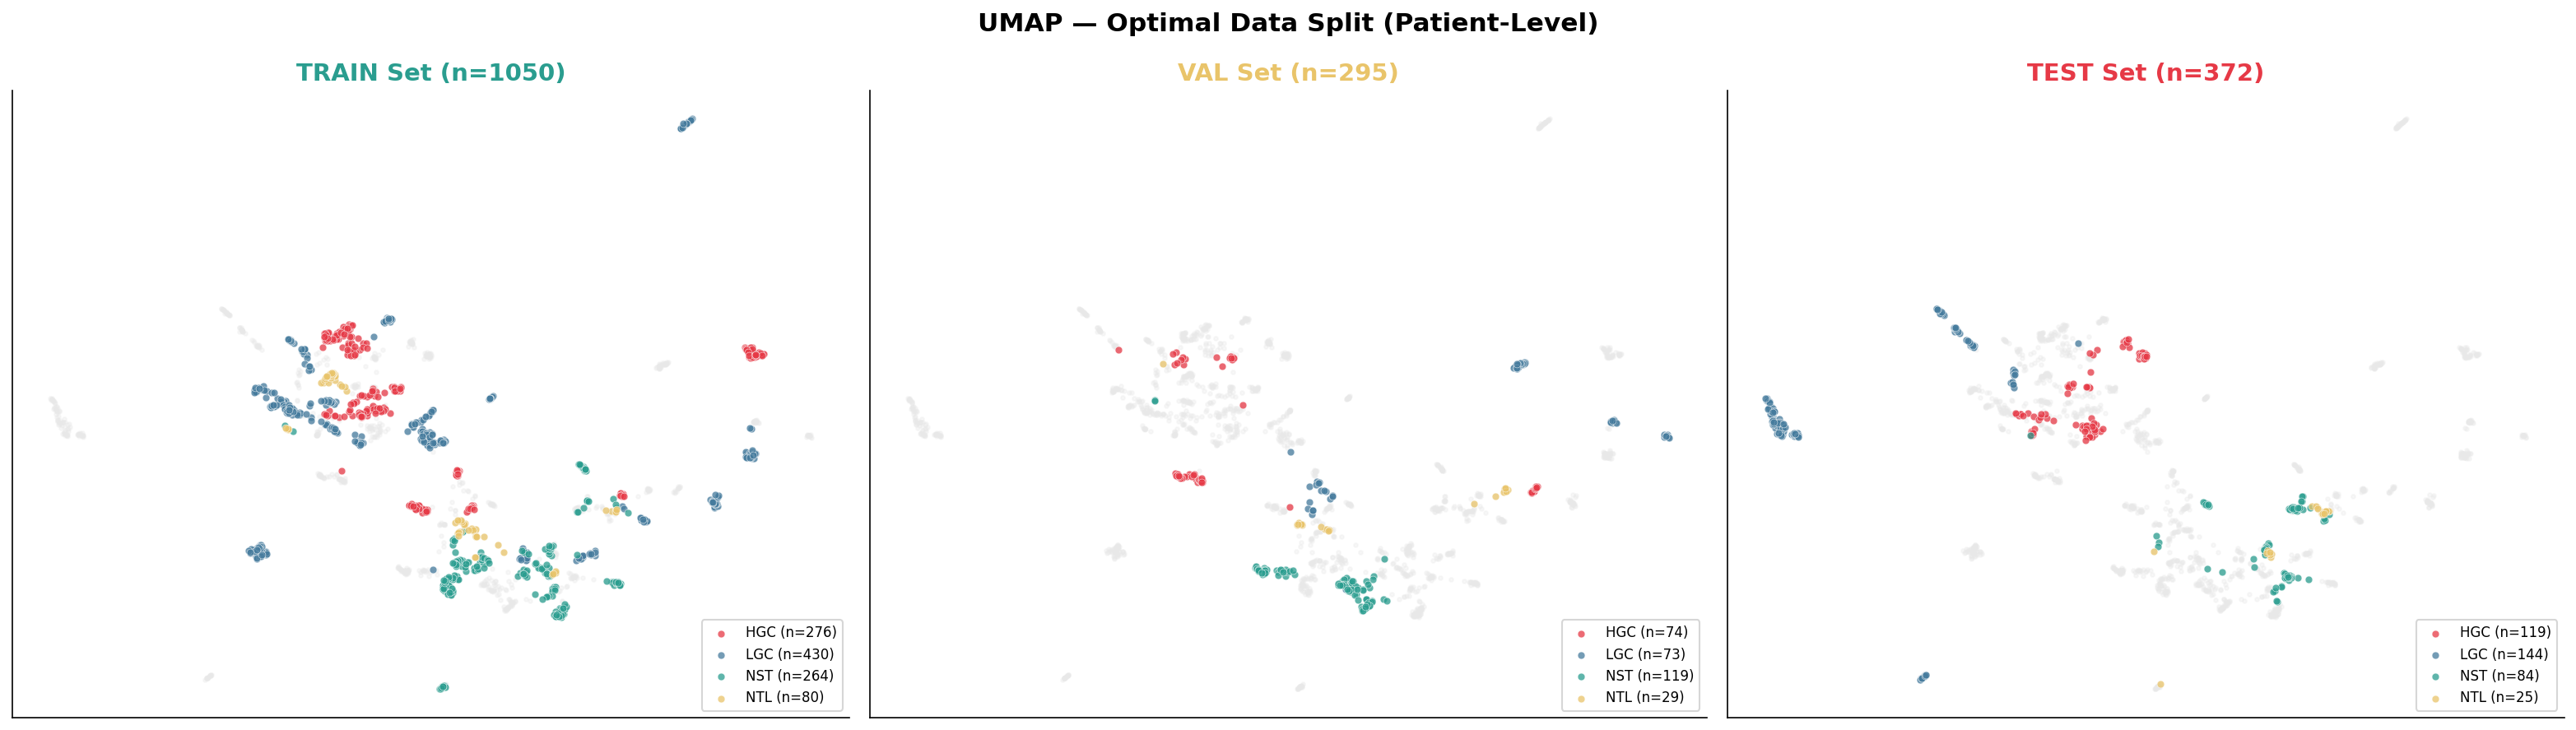

✓ Split visualization saved


In [35]:
# ──────────────────────────────────────────────────────────────
# 16. Visualize the Chosen Split on UMAP
# ──────────────────────────────────────────────────────────────

split_labels = np.array(["train"] * len(df_feat))
split_labels[val_idx] = "val"
split_labels[test_idx] = "test"

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
split_colors = {"train": "#2A9D8F", "val": "#E9C46A", "test": "#E63946"}

for idx_s, (split_name, color) in enumerate(split_colors.items()):
    ax = axes[idx_s]
    mask = split_labels == split_name
    
    ax.scatter(
        embedding_umap[:, 0], embedding_umap[:, 1],
        c="#e8e8e8", s=5, alpha=0.3, rasterized=True,
    )
    for cls in CLASS_NAMES:
        cls_mask = mask & (labels == cls)
        ax.scatter(
            embedding_umap[cls_mask, 0], embedding_umap[cls_mask, 1],
            c=PALETTE[cls], s=18, alpha=0.75,
            edgecolors="white", linewidths=0.3,
            label=f"{cls} (n={cls_mask.sum()})",
            rasterized=True,
        )
    
    n_total = mask.sum()
    ax.set_title(f"{split_name.upper()} Set (n={n_total})",
                 fontweight="bold", fontsize=14, color=color)
    ax.legend(fontsize=8, loc="lower right", frameon=True, fancybox=True)
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle("UMAP — Optimal Data Split (Patient-Level)",
             fontsize=15, fontweight="bold")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "umap_optimal_split.png", bbox_inches="tight", dpi=300)
fig.savefig(OUTPUT_DIR / "umap_optimal_split.pdf", bbox_inches="tight")
plt.show()
print(f"✓ Split visualization saved")

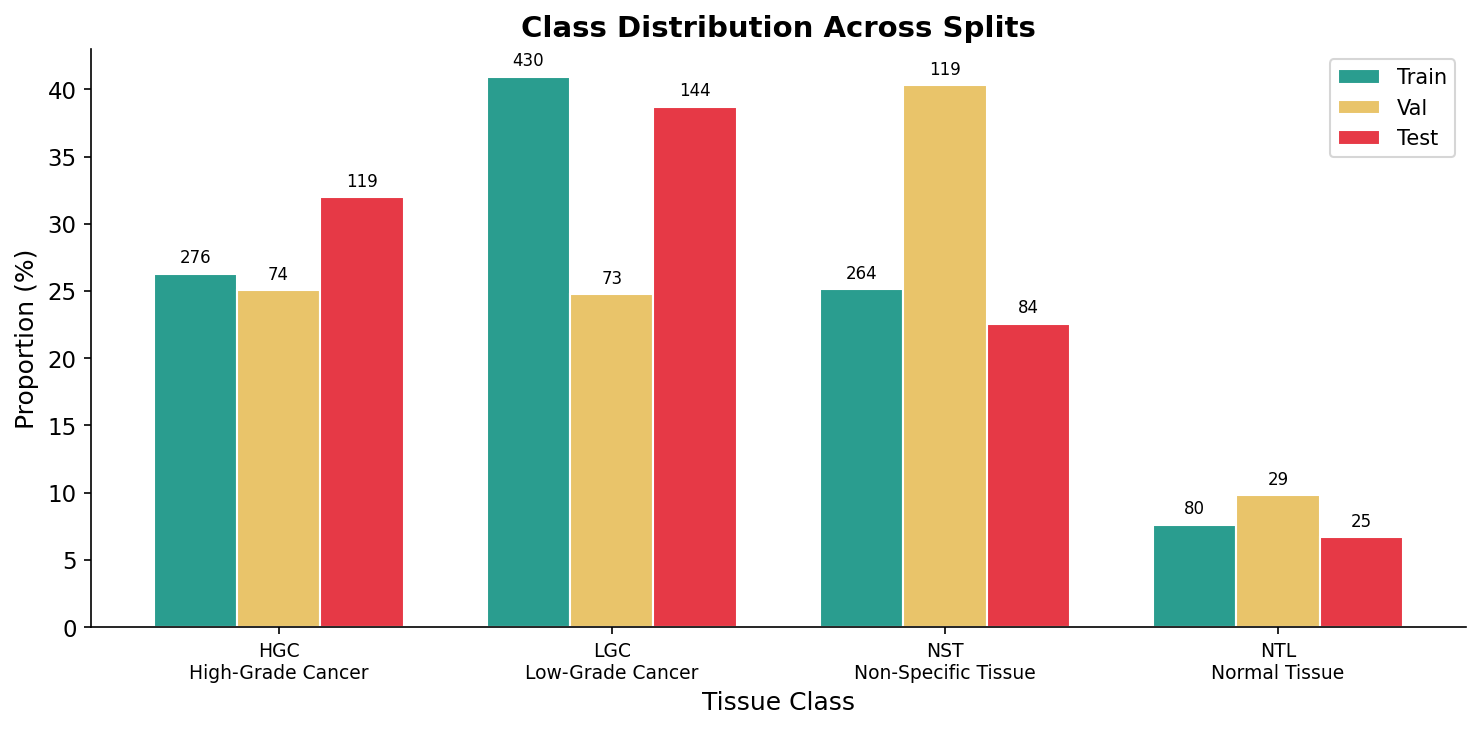

In [36]:
# ──────────────────────────────────────────────────────────────
# 17. Distribution Bar Charts (Tissue Class & Imaging Modality)
# ──────────────────────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [2, 1]})

# --- Subplot 1: Tissue Class Distribution ---
split_data = []
for split_name, idx in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
    counts = Counter(labels[idx])
    total = len(idx)
    for cls in CLASS_NAMES:
        split_data.append({
            "Split": split_name,
            "Class": cls,
            "Count": counts.get(cls, 0),
            "Proportion": counts.get(cls, 0) / total * 100,
        })

split_df = pd.DataFrame(split_data)
x = np.arange(len(CLASS_NAMES))
width = 0.25
split_bar_colors = {"Train": "#2A9D8F", "Val": "#E9C46A", "Test": "#E63946"}

for i, split_name in enumerate(["Train", "Val", "Test"]):
    subset = split_df[split_df["Split"] == split_name]
    bars = ax1.bar(
        x + i * width, subset["Proportion"],
        width, label=split_name, color=split_bar_colors[split_name],
        edgecolor="white",
    )
    for bar, count in zip(bars, subset["Count"]):
        ax1.text(
            bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(count), ha="center", va="bottom", fontsize=8,
        )

ax1.set_xlabel("Tissue Class")
ax1.set_ylabel("Proportion (%)")
ax1.set_title("Class Distribution Across Splits", fontweight="bold")
ax1.set_xticks(x + width)
ax1.set_xticklabels([f"{c}
{CLASS_LABELS_FULL[c]}" for c in CLASS_NAMES], fontsize=9)
ax1.legend(fontsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Subplot 2: Imaging Modality Distribution ---
img_types = df_feat["imaging_type"].values
IMG_CLASSES = ["WLI", "NBI"]
img_data = []

for split_name, idx in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
    counts = Counter(img_types[idx])
    total = len(idx)
    for cls in IMG_CLASSES:
        img_data.append({
            "Split": split_name,
            "Class": cls,
            "Count": counts.get(cls, 0),
            "Proportion": counts.get(cls, 0) / total * 100,
        })

img_df = pd.DataFrame(img_data)
x_img = np.arange(len(IMG_CLASSES))

for i, split_name in enumerate(["Train", "Val", "Test"]):
    subset = img_df[img_df["Split"] == split_name]
    bars = ax2.bar(
        x_img + i * width, subset["Proportion"],
        width, label=split_name, color=split_bar_colors[split_name],
        edgecolor="white",
    )
    for bar, count in zip(bars, subset["Count"]):
        ax2.text(
            bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(count), ha="center", va="bottom", fontsize=8,
        )

ax2.set_xlabel("Imaging Modality")
ax2.set_title("Modality Distribution Across Splits", fontweight="bold")
ax2.set_xticks(x_img + width)
ax2.set_xticklabels(IMG_CLASSES, fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "distributions_split.png", bbox_inches="tight", dpi=300)
plt.show()


In [37]:
# ──────────────────────────────────────────────────────────────
# 18. Compare with Original Split
# ──────────────────────────────────────────────────────────────

if "sub_dataset" in df_feat.columns:
    print("Original split from annotations_fixed.csv:")
    orig_split = df_feat["sub_dataset"].str.strip()
    print(orig_split.value_counts().to_string())
    print()
    
    orig_train = np.where(orig_split == "train")[0]
    orig_val = np.where(orig_split == "val")[0]
    orig_test = np.where(orig_split == "test")[0]
    
    orig_train_pts = set(df_feat.iloc[orig_train]["patient_id"])
    orig_val_pts = set(df_feat.iloc[orig_val]["patient_id"])
    orig_test_pts = set(df_feat.iloc[orig_test]["patient_id"])
    
    leakage_tv = orig_train_pts & orig_val_pts
    leakage_tt = orig_train_pts & orig_test_pts
    leakage_vt = orig_val_pts & orig_test_pts
    
    print(f"Patient leakage in ORIGINAL split:")
    print(f"  Train ∩ Val:  {len(leakage_tv)} patients {leakage_tv if leakage_tv else ''}")
    print(f"  Train ∩ Test: {len(leakage_tt)} patients {leakage_tt if leakage_tt else ''}")
    print(f"  Val ∩ Test:   {len(leakage_vt)} patients {leakage_vt if leakage_vt else ''}")
    
    if len(orig_train) > 0 and len(np.unique(labels_enc[orig_train])) > 1:
        orig_sil_train = silhouette_score(features_scaled[orig_train], labels_enc[orig_train])
    else:
        orig_sil_train = float('nan')
    
    print(f"\nComparison — Silhouette (Train):")
    print(f"  Original: {orig_sil_train:.4f}")
    print(f"  Optimal:  {best_metrics.get('train_silhouette', float('nan')):.4f}")
else:
    print("No 'sub_dataset' column found — skipping comparison.")

Original split from annotations_fixed.csv:
sub_dataset
train    1241
test      284
val       192

Patient leakage in ORIGINAL split:
  Train ∩ Val:  0 patients 
  Train ∩ Test: 0 patients 
  Val ∩ Test:   0 patients 

Comparison — Silhouette (Train):
  Original: 0.0521
  Optimal:  0.0415


In [38]:
# ──────────────────────────────────────────────────────────────
# 19. Export the Optimal Split
# ──────────────────────────────────────────────────────────────

df_feat = df_feat.copy()
df_feat["optimal_split"] = "train"
df_feat.iloc[val_idx, df_feat.columns.get_loc("optimal_split")] = "val"
df_feat.iloc[test_idx, df_feat.columns.get_loc("optimal_split")] = "test"

output_csv = DATA_ROOT / "annotations_optimal_split.csv"
export_cols = ["filename", "imaging_type", "tissue_type", "optimal_split", "patient_id", "case_id"]
df_feat[export_cols].to_csv(output_csv, index=False)
print(f"✓ Optimal split saved to: {output_csv}")
print(f"  Rows: {len(df_feat)}")
print(f"\nSplit counts:")
print(df_feat["optimal_split"].value_counts().to_string())

✓ Optimal split saved to: /teamspace/studios/this_studio/ebt-22/EndoscopicBladderTissue/annotations_optimal_split.csv
  Rows: 1717

Split counts:
optimal_split
train    1050
test      372
val       295


In [39]:
# ──────────────────────────────────────────────────────────────
# 20. Patient → Split Assignment Table
# ──────────────────────────────────────────────────────────────

patient_split_table = df_feat.groupby(["case_id", "patient_id", "tissue_type", "optimal_split"]).size()
patient_split_table = patient_split_table.reset_index(name="n_images")
patient_split_table = patient_split_table.sort_values(["optimal_split", "tissue_type", "case_id"])

print("\nPatient assignment to splits:")
print(patient_split_table.to_string(index=False))


Patient assignment to splits:
 case_id  patient_id tissue_type optimal_split  n_images
       4           4         HGC          test        62
      10          10         HGC          test        57
      13          13         LGC          test       144
       4           4         NST          test        12
       7           7         NST          test        32
      10          10         NST          test        38
      13          13         NST          test         2
       7           7         NTL          test         2
      10          10         NTL          test        23
       2           2         HGC         train        26
       8           8         HGC         train        97
      16          16         HGC         train        58
      24          24         HGC         train        95
       5           5         LGC         train       199
       9           9         LGC         train        35
      11          11         LGC         train        53


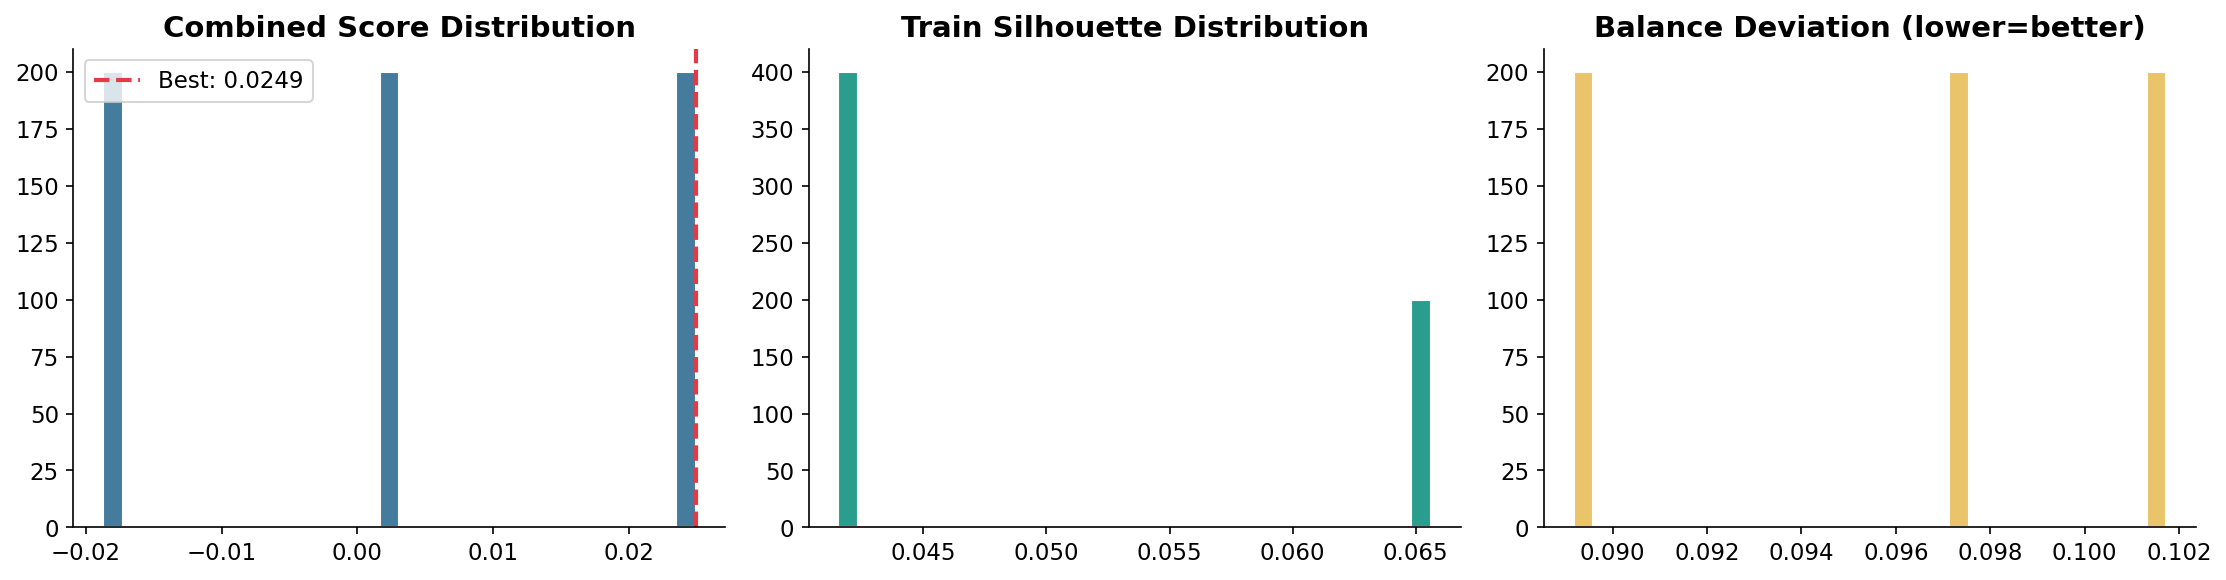

In [40]:
# ──────────────────────────────────────────────────────────────
# 21. Score Distribution Across All Evaluated Splits
# ──────────────────────────────────────────────────────────────

if all_results:
    scores_df = pd.DataFrame(all_results)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    axes[0].hist(scores_df["combined_score"], bins=30, color="#457B9D", edgecolor="white")
    axes[0].axvline(best_score, color="#E63946", ls="--", lw=2, label=f"Best: {best_score:.4f}")
    axes[0].set_title("Combined Score Distribution", fontweight="bold")
    axes[0].legend()
    
    if "train_silhouette" in scores_df.columns:
        axes[1].hist(scores_df["train_silhouette"].dropna(), bins=30, color="#2A9D8F", edgecolor="white")
        axes[1].set_title("Train Silhouette Distribution", fontweight="bold")
    
    axes[2].hist(scores_df["balance_deviation"], bins=30, color="#E9C46A", edgecolor="white")
    axes[2].set_title("Balance Deviation (lower=better)", fontweight="bold")
    
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "split_search_scores.png", bbox_inches="tight", dpi=300)
    plt.show()

In [41]:
# ──────────────────────────────────────────────────────────────
# 22. Final Summary
# ──────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"\n📊 Dataset: {len(df_feat)} images, {df_feat['patient_id'].nunique()} patients, {df_feat['case_id'].nunique()} cases")
print(f"📐 Feature dim: {features.shape[1]} (DINOv2 ViT-B/14: 768-d + DenseNet121: 1024-d, frozen)")
print(f"📦 Cache: v3-compatible per-image .pt format (mean-pooled across patches)")
print(f"\n🎨 Figures saved to: {OUTPUT_DIR}/")
print(f"   • hero_umap_tsne.png / .pdf    ← MAIN PAPER FIGURE")
print(f"   • umap_per_class.png / .pdf     ← supplementary")
print(f"   • umap_imaging_type.png         ← modality analysis")
print(f"   • umap_optimal_split.png / .pdf ← split visualization")
print(f"   • distributions_split.png  ← distribution chart")
print(f"   • split_search_scores.png       ← search analysis")
print(f"\n📁 New split CSV: {output_csv}")
print(f"\n✅ No patient leakage across splits")
print(f"✅ Patient-level grouping respected")
print(f"✅ All classes represented in all splits")


SUMMARY

📊 Dataset: 1717 images, 22 patients, 22 cases
📐 Feature dim: 1792 (DINOv2 ViT-B/14: 768-d + DenseNet121: 1024-d, frozen)
📦 Cache: v3-compatible per-image .pt format (mean-pooled across patches)

🎨 Figures saved to: Output/datasplit_figures/
   • hero_umap_tsne.png / .pdf    ← MAIN PAPER FIGURE
   • umap_per_class.png / .pdf     ← supplementary
   • umap_imaging_type.png         ← modality analysis
   • umap_optimal_split.png / .pdf ← split visualization
   • class_distribution_split.png  ← distribution chart
   • split_search_scores.png       ← search analysis

📁 New split CSV: /teamspace/studios/this_studio/ebt-22/EndoscopicBladderTissue/annotations_optimal_split.csv

✅ No patient leakage across splits
✅ Patient-level grouping respected
✅ All classes represented in all splits
